## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





56.00000000000001
[np.float64(60.0), np.float64(45.97156398104265), np.float64(49.63680387409201), np.float64(48.61788617886179), np.float64(51.65238678090576), np.float64(47.8900883218842), np.float64(50.45045045045045), np.float64(48.69992972593113), np.float64(48.0), np.float64(48.93267651888342), np.float64(49.876786594381464), np.float64(51.72568354997759), np.float64(48.66420057542129), np.float64(49.772209567198175), np.float64(51.12834978843441), np.float64(49.21000658327847), np.float64(51.85185185185185), np.float64(49.85473561882626), np.float64(49.69813391877058), np.float64(50.15600624024961), np.float64(50.172924901185766), np.float64(49.811764705882354), np.float64(49.079065588499546), np.float64(49.54877524709927), np.float64(50.2677100494234), np.float64(49.653945026695666), np.float64(49.30595170184446), np.float64(50.44863578099249), np.float64(49.567367119901114), np.float64(49.73572037510656), np.float64(50.28844568979727), np.float64(50.53437549848461), np.float64

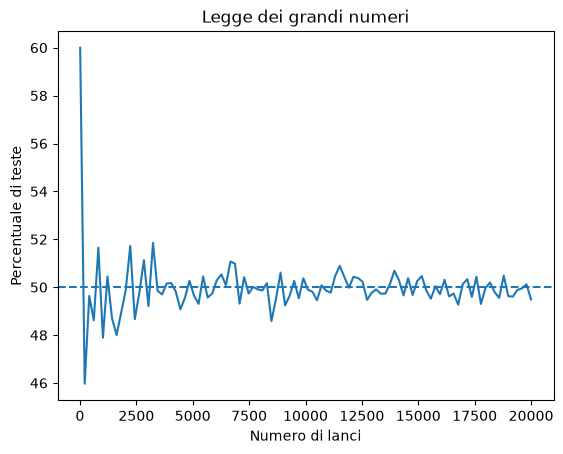

In [23]:
import numpy as np

# Funziona che simuula il lancio
def frequenza_teste(N):
    lanci = np.random.choice(["testa", "croce"], size=N)
    
    frequenza = np.mean(lanci == "testa") * 100
    
    return frequenza

print(frequenza_teste(100))

# Utilizzo campioni diversi
dimensioni = np.linspace(10, 20000, 100, dtype=int)

frequenze = []

for N in dimensioni:
    frequenze.append(frequenza_teste(N))

print(frequenze)

import matplotlib.pyplot as plt

# Grafico delle percentuali di testa
plt.plot(dimensioni, frequenze)

plt.xlabel("Numero di lanci")
plt.ylabel("Percentuale di teste")
plt.title("Legge dei grandi numeri")

plt.axhline(50, linestyle="--")

plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [24]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


(891, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
0
0
Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64
177


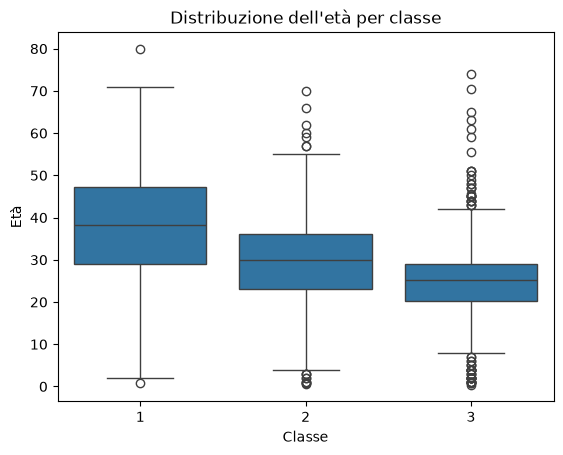

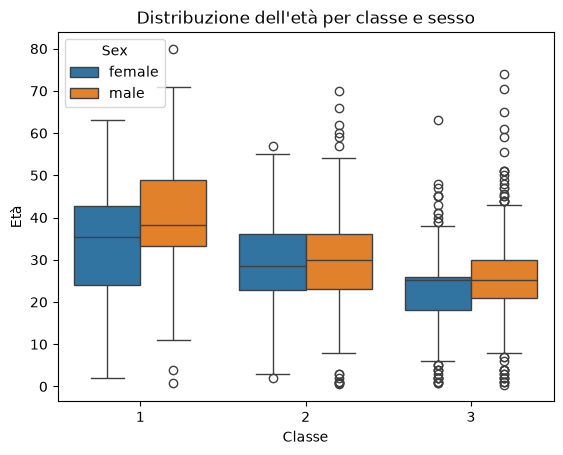

In [25]:
# Visualizzo righe e colonne
print(df.shape)

# Conto i valori mancanti
print(df.isnull().sum())

# Riempio i valori vuoti e controllo
moda_embarked = df["Embarked"].mode()[0]

df["Embarked"] = df["Embarked"].fillna(moda_embarked)

print(df["Embarked"].isnull().sum())

# Conto le righe duplicate
print(df.duplicated().sum())

# Calcolo valore medio e riempio se ci osno valori vuoti
eta_media_classe = df.groupby("Pclass")["Age"].mean()

print(eta_media_classe)

print(df["Age"].isnull().sum())

df["Age"] = df["Age"].fillna(df["Pclass"].map(eta_media_classe))

# Distribuzioni età per classe
sns.boxplot(
    data=df,
    x="Pclass",
    y="Age"
)

plt.xlabel("Classe")
plt.ylabel("Età")
plt.title("Distribuzione dell'età per classe")

plt.show()

# Distribuzioni con uomo e donna
sns.boxplot(
    data=df,
    x="Pclass",
    y="Age",
    hue="Sex"
)

plt.xlabel("Classe")
plt.ylabel("Età")
plt.title("Distribuzione dell'età per classe e sesso")

plt.show()

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
            petal_length  petal_width
species                              
setosa             1.462        0.246
versicolor         4.260        1.326
virginica          5.552        2.026


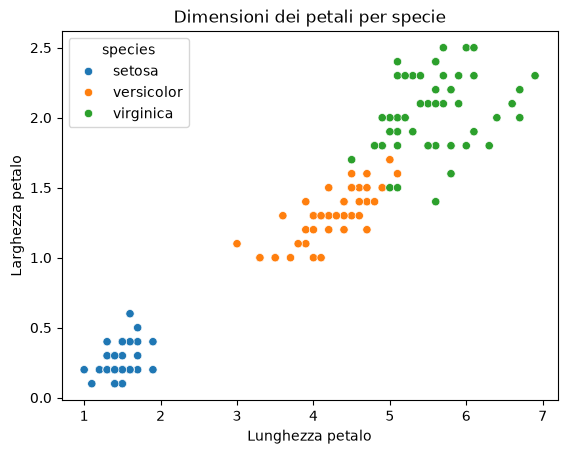

species
setosa         0.3656
versicolor     5.7204
virginica     11.2962
Name: petal_area, dtype: float64


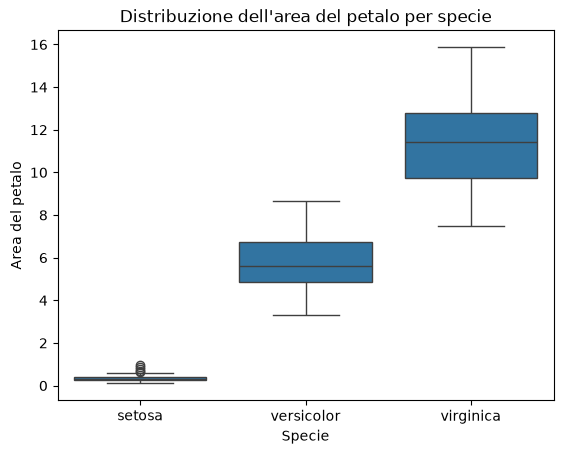

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

# Conto quanti campioni per specie
print(df["species"].value_counts())

# Calcolo le medie di lunghezza e larghezza
medie_petali = df.groupby("species")[["petal_length", "petal_width"]].mean()

print(medie_petali)

# Creo lo scatterplot
sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species"
)

plt.xlabel("Lunghezza petalo")
plt.ylabel("Larghezza petalo")
plt.title("Dimensioni dei petali per specie")

plt.show()

# CReo la colonna con l'area e la analizzo con la media
df["petal_area"] = df["petal_length"] * df["petal_width"]

df.head()

area_media = df.groupby("species")["petal_area"].mean()

print(area_media)

# Boxplot con la nuova colonna
sns.boxplot(
    data=df,
    x="species",
    y="petal_area"
)

plt.xlabel("Specie")
plt.ylabel("Area del petalo")
plt.title("Distribuzione dell'area del petalo per specie")

plt.show()
